In [1]:
# Import libraries for gradient boosting models and light hyperparameter tuning
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import matplotlib.pyplot as plt

In [2]:
# Load the same time-based split used in prior weeks (X months -> train, latest month -> test)
train_df = pd.read_csv("output/train.csv")
test_df = pd.read_csv("output/test.csv")

X_train_full = train_df.drop(columns=["ClosePrice"])
y_train = train_df["ClosePrice"]
X_test_full = test_df.drop(columns=["ClosePrice"])
y_test = test_df["ClosePrice"]

print(X_train_full.shape, X_test_full.shape)

(173243, 72) (12434, 72)


In [3]:
# Set aside a validation slice purely for hyperparameter tuning
# (the true test month is untouched until final evaluation, so this doesn't leak into the real test score)
X_tr, X_val, y_tr, y_val = train_test_split(X_train_full, y_train, test_size=0.15, random_state=42)

print(X_tr.shape, X_val.shape)

(147256, 72) (25987, 72)


In [4]:
# Same evaluation pattern as Weeks 5-6, so results are directly comparable
def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    mae = mean_absolute_error(y_test, test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    mape = np.mean(np.abs((y_test - test_pred) / y_test)) * 100
    mdape = np.median(np.abs((y_test - test_pred) / y_test)) * 100

    print(f"{name}")
    print("-" * len(name))
    print(f"Train R²: {train_r2:.4f}   Test R²: {test_r2:.4f}")
    print(f"Test MAE: ${mae:,.0f}   Test RMSE: ${rmse:,.0f}")
    print(f"Test MAPE: {mape:.2f}%   Test MdAPE: {mdape:.2f}%\n")

    return {"Model": name, "Train_R2": train_r2, "Test_R2": test_r2, "MAE": mae, "RMSE": rmse, "MAPE": mape, "MdAPE": mdape}

In [5]:
# Small, deliberately light grid over the three parameters called out in the assignment
param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 300],
}

def tune_model(model_class, param_grid, X_tr, y_tr, X_val, y_val, fixed_params=None):
    """Light grid search: train each combo on X_tr, score on X_val, keep the best by R²."""
    fixed_params = fixed_params or {}
    best_score = -np.inf
    best_params = None
    all_runs = []

    for params in ParameterGrid(param_grid):
        model = model_class(**params, **fixed_params)
        model.fit(X_tr, y_tr)
        val_r2 = r2_score(y_val, model.predict(X_val))
        all_runs.append({**params, "Val_R2": val_r2})

        if val_r2 > best_score:
            best_score = val_r2
            best_params = params

    return best_params, best_score, pd.DataFrame(all_runs).sort_values("Val_R2", ascending=False)

In [6]:
# Grid search XGBoost over the validation slice
xgb_best_params, xgb_best_val_r2, xgb_grid_results = tune_model(
    XGBRegressor,
    param_grid,
    X_tr, y_tr, X_val, y_val,
    fixed_params={"random_state": 42, "n_jobs": -1},
)

print("Best XGBoost params:", xgb_best_params)
print("Best validation R²:", round(xgb_best_val_r2, 4))
xgb_grid_results.head()

Best XGBoost params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
Best validation R²: 0.844


,learning_rate,max_depth,n_estimators,Val_R2
11,0.10,7,300,0.843992
9,0.10,5,300,0.811279
5,0.05,7,300,0.810991
10,0.10,7,100,0.792755
3,0.05,5,300,0.770670


In [7]:
# Grid search LightGBM over the same validation slice and parameter grid
lgbm_best_params, lgbm_best_val_r2, lgbm_grid_results = tune_model(
    LGBMRegressor,
    param_grid,
    X_tr, y_tr, X_val, y_val,
    fixed_params={"random_state": 42, "n_jobs": -1, "verbose": -1},
)

print("Best LightGBM params:", lgbm_best_params)
print("Best validation R²:", round(lgbm_best_val_r2, 4))
lgbm_grid_results.head()

Best LightGBM params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
Best validation R²: 0.8347


,learning_rate,max_depth,n_estimators,Val_R2
11,0.10,7,300,0.834707
9,0.10,5,300,0.812073
5,0.05,7,300,0.798088
10,0.10,7,100,0.773522
3,0.05,5,300,0.770483


In [8]:
# Retrain on the FULL training set (not just the tuning slice) using each model's best params,
# then evaluate on the real held-out test month for the first time
xgb_final = XGBRegressor(**xgb_best_params, random_state=42, n_jobs=-1)
xgb_final.fit(X_train_full, y_train)

lgbm_final = LGBMRegressor(**lgbm_best_params, random_state=42, n_jobs=-1, verbose=-1)
lgbm_final.fit(X_train_full, y_train)

results = []
results.append(evaluate_model(xgb_final, X_train_full, y_train, X_test_full, y_test, f"XGBoost (best: {xgb_best_params})"))
results.append(evaluate_model(lgbm_final, X_train_full, y_train, X_test_full, y_test, f"LightGBM (best: {lgbm_best_params})"))

results_df = pd.DataFrame(results)
results_df

XGBoost (best: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300})
---------------------------------------------------------------------------
Train R²: 0.8735   Test R²: 0.8509
Test MAE: $203,883   Test RMSE: $329,486
Test MAPE: 18.59%   Test MdAPE: 12.15%

LightGBM (best: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300})
----------------------------------------------------------------------------
Train R²: 0.8501   Test R²: 0.8371
Test MAE: $217,549   Test RMSE: $344,345
Test MAPE: 20.07%   Test MdAPE: 13.58%



,Model,Train_R2,Test_R2,MAE,RMSE,MAPE,MdAPE
0,"XGBoost (best: {'learning_rate': 0.1, 'max_dep...",0.873451,0.850876,203882.610439,329486.146891,18.585886,12.152673
1,"LightGBM (best: {'learning_rate': 0.1, 'max_de...",0.850065,0.837123,217549.436707,344344.728159,20.068749,13.578526


In [9]:
# compare the new gradient boosting models
full_comparison = results_df.sort_values("Test_R2", ascending=False).reset_index(drop=True)
full_comparison

,Model,Train_R2,Test_R2,MAE,RMSE,MAPE,MdAPE
0,"XGBoost (best: {'learning_rate': 0.1, 'max_dep...",0.873451,0.850876,203882.610439,329486.146891,18.585886,12.152673
1,"LightGBM (best: {'learning_rate': 0.1, 'max_de...",0.850065,0.837123,217549.436707,344344.728159,20.068749,13.578526


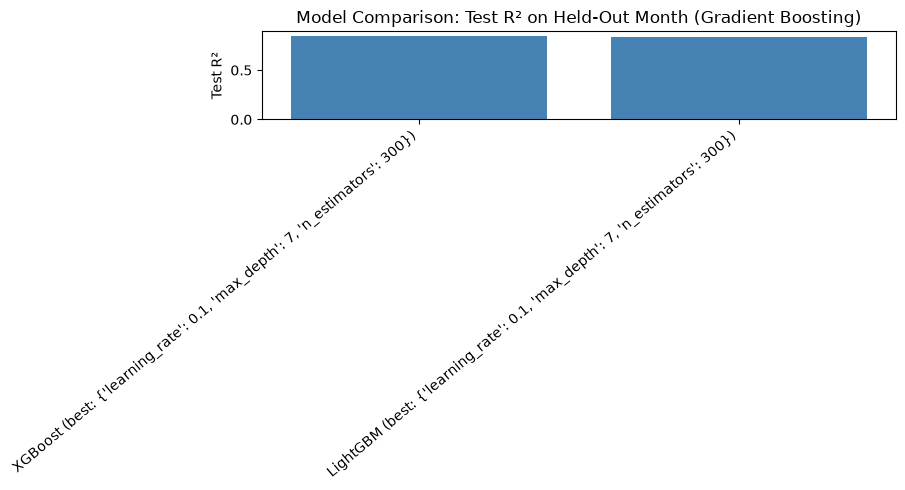

In [10]:
# Visualize test R² across the gradient boosting models
plt.figure(figsize=(9, 5))
plt.bar(full_comparison["Model"], full_comparison["Test_R2"], color="steelblue")
plt.ylabel("Test R²")
plt.title("Model Comparison: Test R² on Held-Out Month (Gradient Boosting)")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

In [11]:
# Check which features the top gradient boosting model relies on most
best_model_name = full_comparison.iloc[0]["Model"]
best_booster = xgb_final if "XGBoost" in best_model_name else lgbm_final

importance_df = pd.DataFrame({
    "Feature": X_train_full.columns,
    "Importance": best_booster.feature_importances_,
}).sort_values("Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
56,CountyOrParish_Santa Clara,0.137040
46,CountyOrParish_Riverside,0.111325
49,CountyOrParish_San Bernardino,0.099471
54,CountyOrParish_San Mateo,0.099418
2,BathroomsTotalInteger,0.069353
41,CountyOrParish_Orange,0.052406
26,CountyOrParish_Kern,0.032365
6,LivingArea_was_missing,0.026947
35,CountyOrParish_Merced,0.023080
13,CountyOrParish_Butte,0.022541


In [12]:
# Save full test metrics for all models, satisfying the "test metrics" deliverable requirement
full_comparison.to_csv("output/week7_advanced_model_metrics.csv", index=False)
print("Saved output/week7_advanced_model_metrics.csv")

Saved output/week7_advanced_model_metrics.csv
